**Loading the Dataset**

In [37]:
#Import libraries
import sys
print(sys.executable)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow_hub as hub
import textattack
from textattack.models.wrappers import ModelWrapper
# Load the training data

#Replace the path above with the folder where YOUR file is saved
#Example: train_data = pd.read_csv("C:/Users/YourName/Documents/train.csv")
df = pd.read_csv("C:\\Users\\pande\\archive\\spam.csv", encoding='latin-1')
df.head()


c:\Program Files (x86)\Microsoft Visual Studio\Shared\Python39_64\python.exe


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


**Basic Data Cleaning (Preprocessing)**

In [38]:
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df = df.rename(columns={'v1': 'label', 'v2': 'Text'})
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()

,label,Text,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


**Splitting the Data**

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Text'],
    df['label_enc'],
    test_size=0.2,
    random_state=42
)

X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

In [40]:
avg_words_len = round(sum([len(i.split())
                      for i in df['Text']]) / len(df['Text']))
total_words_length = len(set(" ".join(df['Text']).split()))

print(f"Data Loaded. Training samples: {len(X_train_np)}")
print(f"Average words per message: {avg_words_len}")
print(f"Approximate vocabulary size: {total_words_length}")

Data Loaded. Training samples: 4457
Average words per message: 15
Approximate vocabulary size: 15585


In [41]:
def compile_and_fit(model, epochs=5):
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train_np,
        y_train_np,
        epochs=epochs,
        validation_data=(X_test_np, y_test_np)
    )
    return history

def get_metrics(model, X, y):
    y_preds = np.round(model.predict(X))
    return {
        'accuracy': accuracy_score(y, y_preds),
        'precision': precision_score(y, y_preds),
        'recall': recall_score(y, y_preds),
        'f1-score': f1_score(y, y_preds)
    }

In [42]:
from tensorflow.keras.layers import TextVectorization
text_vec = TextVectorization(
    max_tokens=total_words_length,
    standardize='lower_and_strip_punctuation',
    output_mode='int',
    output_sequence_length=avg_words_len
)
text_vec.adapt(X_train_np)

**Training a Basic Classification Model**

In [43]:

input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_1 = keras.Model(input_layer, output_layer, name="Dense_Model")
history_1 = compile_and_fit(model_1)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8827 - loss: 0.3796 - val_accuracy: 0.9668 - val_loss: 0.1601
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9773 - loss: 0.0962 - val_accuracy: 0.9758 - val_loss: 0.0867
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9946 - loss: 0.0265 - val_accuracy: 0.9803 - val_loss: 0.0795
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9968 - loss: 0.0202 - val_accuracy: 0.9803 - val_loss: 0.0819
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9971 - loss: 0.0116 - val_accuracy: 0.9794 - val_loss: 0.0846


In [44]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_2 = keras.Model(input_layer, output_layer, name="BiLSTM_Model")
history_2 = compile_and_fit(model_2)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9080 - loss: 0.2840 - val_accuracy: 0.9785 - val_loss: 0.0915
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9923 - loss: 0.0337 - val_accuracy: 0.9812 - val_loss: 0.0801
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9976 - loss: 0.0092 - val_accuracy: 0.9821 - val_loss: 0.0931
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9998 - loss: 9.1456e-04 - val_accuracy: 0.9812 - val_loss: 0.1136
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 1.0000 - loss: 1.4585e-04 - val_accuracy: 0.9821 - val_loss: 0.1210


In [45]:
use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False,
    input_shape=[],
    dtype=tf.string,
    name='USE'
)
input_layer = layers.Input(shape=[], dtype=tf.string)
embedding = layers.Lambda(lambda x: use_layer(
    x), output_shape=(512,))(input_layer)
x = layers.Dense(64, activation='relu')(embedding)
x = layers.Dropout(0.2)(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)
model_3 = keras.Model(input_layer, output_layer, name="USE_Model")
history_3 = compile_and_fit(model_3)

Epoch 1/5


  0%|          | 0/25 [01:34<?, ?it/s]


140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8702 - loss: 0.4515 - val_accuracy: 0.9695 - val_loss: 0.1158
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9815 - loss: 0.0880 - val_accuracy: 0.9767 - val_loss: 0.0719
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9846 - loss: 0.0567 - val_accuracy: 0.9803 - val_loss: 0.0592
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9850 - loss: 0.0475 - val_accuracy: 0.9830 - val_loss: 0.0540
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9873 - loss: 0.0387 - val_accuracy: 0.9830 - val_loss: 0.0519


In [46]:
results = {
    'Dense Embedding': get_metrics(model_1, X_test_np, y_test_np),
    'Bi-LSTM': get_metrics(model_2, X_test_np, y_test_np),
    'Transfer Learning (USE)': get_metrics(model_3, X_test_np, y_test_np)
}

results_df = pd.DataFrame(results).transpose()
print("Performance Table:")
print(results_df)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Performance Table:
                         accuracy  precision    recall  f1-score
Dense Embedding          0.979372   0.963504  0.880000  0.919861
Bi-LSTM                  0.982063   0.957746  0.906667  0.931507
Transfer Learning (USE)  0.982960   0.958042  0.913333  0.935154


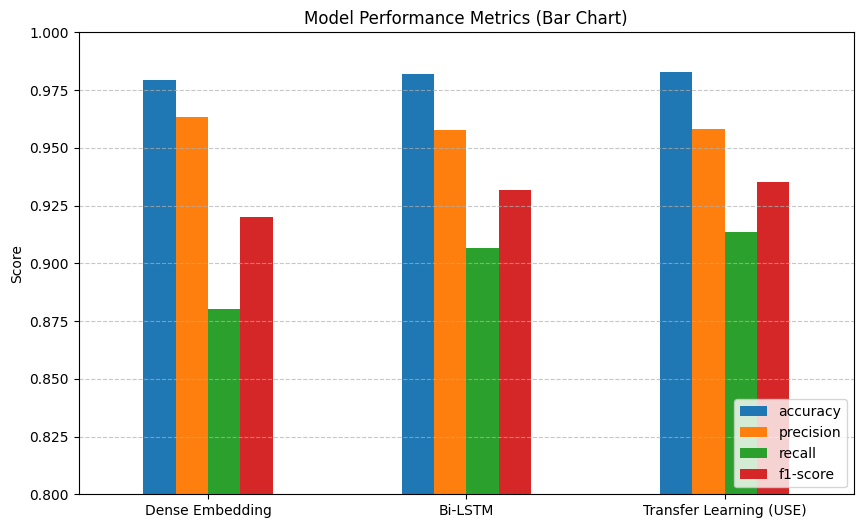

In [47]:
results_df.plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Metrics (Bar Chart)")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

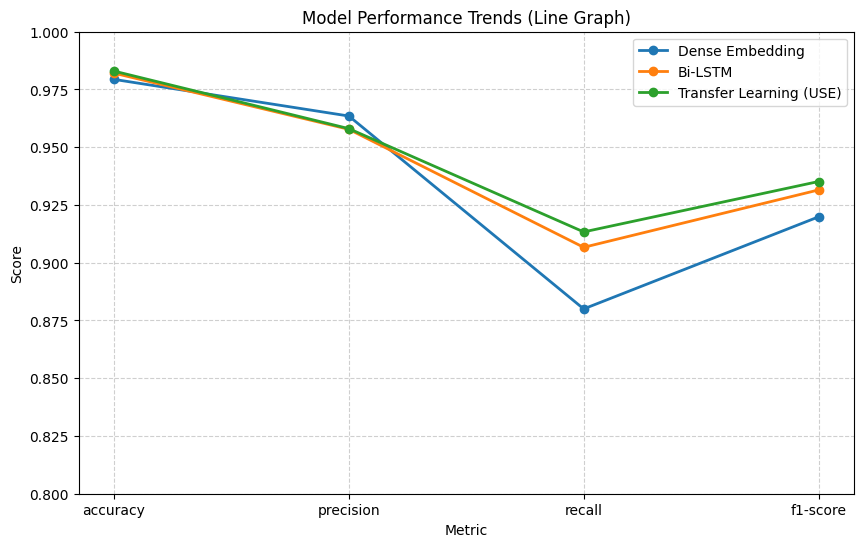

In [48]:
plt.figure(figsize=(10, 6))

for model_name in results_df.index:
    plt.plot(
        results_df.columns,
        results_df.loc[model_name],
        marker='o',
        label=model_name,
        linewidth=2
    )
plt.title("Model Performance Trends (Line Graph)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0.8, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [54]:
#defining wrapper class to use textattack
class CustomModelWrapper:
    def __init__(self,model,):
        self.model=model

    def __call__(self,text):
        inputs = np.array(text).flatten()
        
        # 2. Convert to a TensorFlow String Tensor
        # This is the critical step to fix the 'Invalid dtype' error
        tf_inputs = tf.constant(inputs, dtype=tf.string)
        
        # 3. Get predictions (verbose=0 keeps the console clean during attacks)
        preds = self.model.predict(tf_inputs, verbose=0)
        if preds.shape[1] == 1:
            return np.array([[1-p[0], p[0]] for p in preds])
        return preds
#creating wrapper objects
embed_wrapper=CustomModelWrapper(model_1)
lstm_wrapper=CustomModelWrapper(model_2)
use_wrapper=CustomModelWrapper(model_3)


In [ ]:
from textattack.attack_recipes import TextBuggerLi2018
from textattack.attacker import Attacker,AttackArgs
from textattack.datasets import Dataset

lstm_attack = TextBuggerLi2018.build(lstm_wrapper)
samples = list(zip(X_test,y_test))

# Convert to the TextAttack-specific Dataset format
attack_dataset = Dataset(samples)
attack_args = AttackArgs(
    num_examples=25, 
    log_to_csv="textbugger_results_lstm.csv"
)

attacker = Attacker(lstm_attack, attack_dataset, attack_args)
results = attacker.attack_dataset()

textattack: Unknown if model of class <class 'keras.src.models.functional.Functional'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.
textattack: Logging to CSV at path textbugger_results_lstm.csv


Attack(
  (search_method): GreedyWordSwapWIR(
    (wir_method):  delete
  )
  (goal_function):  UntargetedClassification
  (transformation):  CompositeTransformation(
    (0): WordSwapRandomCharacterInsertion(
        (random_one):  True
      )
    (1): WordSwapRandomCharacterDeletion(
        (random_one):  True
      )
    (2): WordSwapNeighboringCharacterSwap(
        (random_one):  True
      )
    (3): WordSwapHomoglyphSwap
    (4): WordSwapEmbedding(
        (max_candidates):  5
        (embedding):  WordEmbedding
      )
    )
  (constraints): 
    (0): UniversalSentenceEncoder(
        (metric):  angular
        (threshold):  0.8
        (window_size):  inf
        (skip_text_shorter_than_window):  False
        (compare_against_original):  True
      )
    (1): RepeatModification
    (2): StopwordModification
  (is_black_box):  True
) 



--------------------------------------------- Result 1 ---------------------------------------------
[[0 (87%)]] --> [[1 (84%)]]

Funny fact [[Nobody]] teaches volcanoes 2 erupt, tsunamis 2 arise, hurricanes 2 sway aroundn no 1 teaches hw 2 choose a wife Natural disasters just happens

Funny fact [[Everybody]] teaches volcanoes 2 erupt, tsunamis 2 arise, hurricanes 2 sway aroundn no 1 teaches hw 2 choose a wife Natural disasters just happens




--------------------------------------------- Result 2 ---------------------------------------------
[[0 (100%)]] --> [[[FAILED]]]

I sent my scores to sophas and i had to do secondary application for a few schools. I think if you are thinking of applying, do a research on cost also. Contact joke ogunrinde, her school is one me the less expensive ones




--------------------------------------------- Result 3 ---------------------------------------------
[[1 (100%)]] --> [[0 (51%)]]

We [[know]] someone who you know that fancies you. [[Call]] 09058097218 to find out who. POBox 6, LS15HB 150p

We [[knows]] someone who you know that fancies you. [[C]] [[all]] 09058097218 to find out who. POBox 6, LS15HB 150p




...

--------------------------------------------- Result 22 ---------------------------------------------
[[0 (100%)]] --> [[1 (96%)]]

Boy; [[I]] [[love]] u Grl: Hogolo [[Boy]]: gold chain kodstini Grl: Agalla [[Boy]]: necklace madstini Grl: agalla Boy: Hogli 1 mutai eerulli kodthini! Grl: I love U kano;-)

Boy; [[ich]] [[adores]] u Grl: Hogolo [[Bоy]]: gold chain kodstini Grl: Agalla [[Guys]]: necklace madstini Grl: agalla Boy: Hogli 1 mutai eerulli kodthini! Grl: I love U kano;-)




--------------------------------------------- Result 23 ---------------------------------------------
[[0 (100%)]] --> [[[FAILED]]]

A bloo bloo bloo I'll miss the first bowl




--------------------------------------------- Result 24 ---------------------------------------------
[[0 (100%)]] --> [[[FAILED]]]

Yeah sure, give me a couple minutes to track down my wallet








[Succeeded / Failed / Skipped / Total] 8 / 17 / 0 / 25: 100%|██████████| 25/25 [01:21<00:00,  3.28s/it]

--------------------------------------------- Result 25 ---------------------------------------------
[[1 (100%)]] --> [[0 (97%)]]

This is the [[2nd]] time we have [[tried]] [[2]] [[contact]] u. U have won the å£750 Pound prize. 2 claim is easy, call 087187272008 NOW1! Only 10p per minute. BT-national-rate.

This is the [[2]] [[nd]] time we have [[try]] [[ᒿ]] [[cont]] [[act]] u. U have won the å£750 Pound prize. 2 claim is easy, call 087187272008 NOW1! Only 10p per minute. BT-national-rate.



+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 8      |
| Number of failed attacks:     | 17     |
| Number of skipped attacks:    | 0      |
| Original accuracy:            | 100.0% |
| Accuracy under attack:        | 68.0%  |
| Attack success rate:          | 32.0%  |
| Average perturbed word %:     | 52.2%  |
| Average num. words per input: | 16.16  |
| Avg num queries:         

In [56]:
use_attack = TextBuggerLi2018.build(use_wrapper)
samples = list(zip(X_test,y_test))

# Convert to the TextAttack-specific Dataset format
attack_dataset = Dataset(samples)
attack_args = AttackArgs(
    num_examples=25, 
    log_to_csv="textbugger_results_lstm.csv"
)

attacker = Attacker(use_attack, attack_dataset, attack_args)
results = attacker.attack_dataset()

textattack: Unknown if model of class <class 'keras.src.models.functional.Functional'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.
textattack: Logging to CSV at path textbugger_results_lstm.csv


Attack(
  (search_method): GreedyWordSwapWIR(
    (wir_method):  delete
  )
  (goal_function):  UntargetedClassification
  (transformation):  CompositeTransformation(
    (0): WordSwapRandomCharacterInsertion(
        (random_one):  True
      )
    (1): WordSwapRandomCharacterDeletion(
        (random_one):  True
      )
    (2): WordSwapNeighboringCharacterSwap(
        (random_one):  True
      )
    (3): WordSwapHomoglyphSwap
    (4): WordSwapEmbedding(
        (max_candidates):  5
        (embedding):  WordEmbedding
      )
    )
  (constraints): 
    (0): UniversalSentenceEncoder(
        (metric):  angular
        (threshold):  0.8
        (window_size):  inf
        (skip_text_shorter_than_window):  False
        (compare_against_original):  True
      )
    (1): RepeatModification
    (2): StopwordModification
  (is_black_box):  True
) 



--------------------------------------------- Result 1 ---------------------------------------------
[[0 (98%)]] --> [[1 (52%)]]

[[Funny]] fact [[Nobody]] [[teaches]] volcanoes 2 erupt, tsunamis 2 arise, hurricanes 2 sway [[aroundn]] no 1 [[teaches]] [[hw]] 2 choose a [[wife]] Natural disasters just happens

[[Amusing]] fact [[Somebody]] [[teacհes]] volcanoes 2 erupt, tsunamis 2 arise, hurricanes 2 sway [[ɑroundn]] no 1 [[teach]] [[hԝ]] 2 choose a [[femme]] Natural disasters just happens




--------------------------------------------- Result 2 ---------------------------------------------
[[0 (99%)]] --> [[1 (52%)]]

[[I]] sent my scores to sophas and i had to do secondary application for a few [[schools]]. [[I]] [[think]] if you are [[thinking]] of applying, do a research on cost also. Contact [[joke]] ogunrinde, her school is one me the less expensive ones

[[l]] sent my scores to sophas and i had to do secondary application for a few [[academies]]. [[yo]] [[reckon]] if you are [[thoughts]] of applying, do a research on cost also. Contact [[prank]] ogunrinde, her school is one me the less expensive ones


--------------------------------------------- Result 3 ---------------------------------------------
[[0 (67%)]] --> [[[SKIPPED]]]

We know someone who you know that fancies you. Call 09058097218 to find out who. POBox 6, LS15HB 150p




--------------------------------------------- Result 4 ---------------------------------------------
[[0 (100%)]] --> [[[FAILED]]]

Only if you promise your getting out as SOON as you can. And you'll text me in the morning to let me know you made it in ok.




...

--------------------------------------------- Result 22 ---------------------------------------------
[[0 (90%)]] --> [[1 (61%)]]

Boy; I love u [[Grl]]: Hogolo Boy: gold chain kodstini Grl: Agalla Boy: necklace madstini Grl: agalla [[Boy]]: [[Hogli]] 1 mutai eerulli kodthini! [[Grl]]: [[I]] love U kano;-)

Boy; I love u [[Gl]]: Hogolo Boy: gold chain kodstini Grl: Agalla Boy: necklace madstini Grl: agalla [[Guys]]: [[Hogⅼi]] 1 mutai eerulli kodthini! [[Gⲅl]]: [[l]] love U kano;-)




--------------------------------------------- Result 23 ---------------------------------------------
[[0 (100%)]] --> [[[FAILED]]]

A bloo bloo bloo I'll miss the first bowl




--------------------------------------------- Result 24 ---------------------------------------------
[[0 (100%)]] --> [[[FAILED]]]

Yeah sure, give me a couple minutes to track down my wallet








[Succeeded / Failed / Skipped / Total] 5 / 19 / 1 / 25: 100%|██████████| 25/25 [00:22<00:00,  1.12it/s]

--------------------------------------------- Result 25 ---------------------------------------------
[[1 (99%)]] --> [[0 (53%)]]

[[This]] is the 2nd time we have tried 2 [[contact]] u. U have won the å£750 Pound [[prize]]. 2 claim is easy, call 087187272008 NOW1! [[Only]] 10p per minute. BT-national-rate.

[[That]] is the 2nd time we have tried 2 [[liaise]] u. U have won the å£750 Pound [[pri]] [[ze]]. 2 claim is easy, call 087187272008 NOW1! [[Jen]] 10p per minute. BT-national-rate.



+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 5      |
| Number of failed attacks:     | 19     |
| Number of skipped attacks:    | 1      |
| Original accuracy:            | 96.0%  |
| Accuracy under attack:        | 76.0%  |
| Attack success rate:          | 20.83% |
| Average perturbed word %:     | 23.73% |
| Average num. words per input: | 16.16  |
| Avg num queries:              |

In [57]:
embed_attack = TextBuggerLi2018.build(embed_wrapper)
samples = list(zip(X_test,y_test))

# Convert to the TextAttack-specific Dataset format
attack_dataset = Dataset(samples)
attack_args = AttackArgs(
    num_examples=25, 
    log_to_csv="textbugger_results_lstm.csv"
)

attacker = Attacker(embed_attack, attack_dataset, attack_args)
results = attacker.attack_dataset()

textattack: Unknown if model of class <class 'keras.src.models.functional.Functional'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.
textattack: Logging to CSV at path textbugger_results_lstm.csv


Attack(
  (search_method): GreedyWordSwapWIR(
    (wir_method):  delete
  )
  (goal_function):  UntargetedClassification
  (transformation):  CompositeTransformation(
    (0): WordSwapRandomCharacterInsertion(
        (random_one):  True
      )
    (1): WordSwapRandomCharacterDeletion(
        (random_one):  True
      )
    (2): WordSwapNeighboringCharacterSwap(
        (random_one):  True
      )
    (3): WordSwapHomoglyphSwap
    (4): WordSwapEmbedding(
        (max_candidates):  5
        (embedding):  WordEmbedding
      )
    )
  (constraints): 
    (0): UniversalSentenceEncoder(
        (metric):  angular
        (threshold):  0.8
        (window_size):  inf
        (skip_text_shorter_than_window):  False
        (compare_against_original):  True
      )
    (1): RepeatModification
    (2): StopwordModification
  (is_black_box):  True
) 



--------------------------------------------- Result 1 ---------------------------------------------
[[1 (92%)]] --> [[[SKIPPED]]]

Funny fact Nobody teaches volcanoes 2 erupt, tsunamis 2 arise, hurricanes 2 sway aroundn no 1 teaches hw 2 choose a wife Natural disasters just happens




--------------------------------------------- Result 2 ---------------------------------------------
[[0 (100%)]] --> [[[FAILED]]]

I sent my scores to sophas and i had to do secondary application for a few schools. I think if you are thinking of applying, do a research on cost also. Contact joke ogunrinde, her school is one me the less expensive ones




--------------------------------------------- Result 3 ---------------------------------------------
[[1 (99%)]] --> [[0 (54%)]]

We [[know]] someone who you know that [[fancies]] you. [[Call]] 09058097218 to find out who. POBox 6, LS15HB 150p

We [[knows]] someone who you know that [[fancied]] you. [[Ca]] [[ll]] 09058097218 to find out who. POBox 6, LS15HB 150p


--------------------------------------------- Result 4 ---------------------------------------------
[[1 (52%)]] --> [[[SKIPPED]]]

Only if you promise your getting out as SOON as you can. And you'll text me in the morning to let me know you made it in ok.




...

--------------------------------------------- Result 22 ---------------------------------------------
[[0 (99%)]] --> [[1 (63%)]]

[[Boy]]; [[I]] [[love]] u Grl: Hogolo Boy: gold chain kodstini Grl: Agalla [[Boy]]: necklace madstini Grl: agalla Boy: Hogli 1 mutai eerulli kodthini! Grl: I love U kano;-)

[[Guys]]; [[ich]] [[adores]] u Grl: Hogolo Boy: gold chain kodstini Grl: Agalla [[Boу]]: necklace madstini Grl: agalla Boy: Hogli 1 mutai eerulli kodthini! Grl: I love U kano;-)




--------------------------------------------- Result 23 ---------------------------------------------
[[0 (100%)]] --> [[[FAILED]]]

A bloo bloo bloo I'll miss the first bowl




--------------------------------------------- Result 24 ---------------------------------------------
[[0 (100%)]] --> [[[FAILED]]]

Yeah sure, give me a couple minutes to track down my wallet








[Succeeded / Failed / Skipped / Total] 3 / 20 / 2 / 25: 100%|██████████| 25/25 [00:17<00:00,  1.41it/s]

--------------------------------------------- Result 25 ---------------------------------------------
[[1 (100%)]] --> [[0 (54%)]]

[[This]] is the [[2nd]] [[time]] we have [[tried]] [[2]] [[contact]] u. U have won the å£750 Pound prize. 2 claim is easy, call 087187272008 NOW1! Only 10p per minute. BT-national-rate.

[[That]] is the [[2d]] [[times]] we have [[tired]] [[ᒿ]] [[contacts]] u. U have won the å£750 Pound prize. 2 claim is easy, call 087187272008 NOW1! Only 10p per minute. BT-national-rate.



+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 3      |
| Number of failed attacks:     | 20     |
| Number of skipped attacks:    | 2      |
| Original accuracy:            | 92.0%  |
| Accuracy under attack:        | 80.0%  |
| Attack success rate:          | 13.04% |
| Average perturbed word %:     | 32.27% |
| Average num. words per input: | 16.16  |
| Avg num queries: